In [38]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [39]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'is_gesture'

WINDOW_SIZE_SAMPLES = 200
WINDOW_STRIDE_SAMPLES = 25
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians

In [40]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' THEN 'no' ELSE 'yes' END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
),

no_gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        'No Gesture' AS gesture,
        'No Gesture' AS parent_gesture,
        s.participant_id,
        'no' AS is_gesture,
        NULL  AS group_id
    FROM sensorData sd
    LEFT JOIN gesture_samples gs 
      ON gs.id = sd.id -- Check if this row was already labeled as a gesture
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    
    -- Exclude rows that were found in gesture_samples (gs.id IS NULL)
    -- Also keep your original session_task_id and 'Szenarien' filters
    WHERE gs.id IS NULL
      AND sd.session_task_id IN (
          SELECT DISTINCT session_task_id FROM preciseMarker
      )
      AND rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
UNION ALL
SELECT * FROM no_gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [41]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 'no' ELSE 'yes' END AS is_gesture,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 'no' ELSE 'yes' END AS marker_label,
    smt.group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,no,no,2025-10-07 14:11:50
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,no,no,2025-10-07 14:11:50
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,no,no,2025-10-07 14:11:50
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,no,no,2025-10-07 14:11:50
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,no,no,2025-10-07 14:11:50


In [42]:
# print the markerlabel counts in the szenarien_df
print(szenarien_df_raw['marker_label'].value_counts())

marker_label
no     103735
yes      8749
Name: count, dtype: int64


In [43]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [44]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [45]:
df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,timestamp_ms,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,group_id,estimated_timestamp
0,b5e548d8-203e-47f0-b702-d1ccc2ec8d2f,00939e3d-4a5f-4dd7-9bf9-de608222ef04,0,2025-10-03 16:37:53,1759509473000,0,184.268295,2.871814,853.0,3.0,5.046055,357.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Gesture,No Gesture,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,no,None,2025-10-03 16:37:53.000000000
1,0f01ab50-7419-4e90-9303-6f714e120ee2,00939e3d-4a5f-4dd7-9bf9-de608222ef04,1,2025-10-03 16:37:53,1759509473038,0,184.269440,2.860524,913.0,3.0,5.075835,443.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Gesture,No Gesture,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,no,None,2025-10-03 16:37:53.038461538
2,19e590d8-a0cd-4421-bd73-eb44552194a0,00939e3d-4a5f-4dd7-9bf9-de608222ef04,2,2025-10-03 16:37:53,1759509473076,0,184.271744,2.845071,947.0,4.0,5.100462,481.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Gesture,No Gesture,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,no,None,2025-10-03 16:37:53.076923077
3,9c2a60fc-a50e-4272-8d98-88c542b4e6c8,00939e3d-4a5f-4dd7-9bf9-de608222ef04,3,2025-10-03 16:37:53,1759509473115,0,184.273285,2.832931,981.0,4.0,5.127452,494.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Gesture,No Gesture,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,no,None,2025-10-03 16:37:53.115384615
4,3df313c7-daeb-4b01-851c-eecd2af61299,00939e3d-4a5f-4dd7-9bf9-de608222ef04,4,2025-10-03 16:37:53,1759509473153,0,184.276733,2.822655,1019.0,4.0,5.150771,545.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Gesture,No Gesture,6a1b56e6-47ce-43cb-96cb-713d055d8f6d,no,None,2025-10-03 16:37:53.153846154


In [46]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396602 entries, 0 to 396601
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      396602 non-null  object        
 1   session_task_id         396602 non-null  object        
 2   session_task_row_index  396602 non-null  int64         
 3   timestamp               396602 non-null  datetime64[ns]
 4   timestamp_ms            396602 non-null  int64         
 5   button_pressed          396602 non-null  int64         
 6   motor_angle             396602 non-null  float64       
 7   touch_1_position        263381 non-null  float64       
 8   touch_1_pressure        263381 non-null  float64       
 9   touch_1_channel         263381 non-null  float64       
 10  touch_2_position        218142 non-null  float64       
 11  touch_2_pressure        218142 non-null  float64       
 12  touch_2_channel         218142

In [47]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")
df_raw["is_gesture"] = df_raw["is_gesture"].astype("category")

In [48]:
df_raw[LABEL_COLUMN].value_counts()

is_gesture
no     343892
yes     52710
Name: count, dtype: int64

In [49]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [50]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    49949
6331fbd1-76bb-48d6-92a2-80a55a70d134    37711
696b4743-9d39-4fb1-8271-90e7d48652af    26221
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    67623
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    49778
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    48069
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    55706
fdd02af8-c764-43ba-8247-c612f85568b4    61545
dtype: int64

In [51]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [52]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [53]:
# Stabilize dataset
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())

# # Final step: Replace the old columns in your original DataFrame
# # 1. Get non-touch columns from the original df
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

# # 2. Join the non-touch columns with the new stabilized touch data
df_clean = final_df.join(stabilized_touch_data)
print("Stabilization Complete.")

Stabilization Complete.


In [54]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
# Final step: Replace the old columns in your original DataFrame
# 1. Get non-touch columns from the original df
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
# 2. Join the non-touch columns with the new stabilized touch data
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Stabilization of Szenarien Complete.")

Stabilization of Szenarien Complete.


In [55]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(2, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position    190090
touch_1_pressure    190090
touch_1_channel     190090
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            317926
dtype: int64

In [56]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
group_id            0
dtype: int64

In [57]:
# Print the min, max and mean count of samples per group_id
grouped = df_clean.groupby('group_id').size()
print(f"Min samples per group_id: {grouped.min()}")
print(f"Max samples per group_id: {grouped.max()}")
print(f"Mean samples per group_id: {grouped.mean():.2f}")

# Print the parent_gesture for the group_id with the maximum samples
max_group_id = grouped.idxmax()
max_parent_gesture = df_clean[df_clean['group_id'] == max_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with max samples ({max_group_id}): {max_parent_gesture}")

# Print the parent_gesture for the group_id with the minimum samples
min_group_id = grouped.idxmin()
min_parent_gesture = df_clean[df_clean['group_id'] == min_group_id]['parent_gesture'].iloc[0]
print(f"Parent gesture for group_id with min samples ({min_group_id}): {min_parent_gesture}")

# Print the count of samples for the No Gesture parent_gesture that has the max samples
no_gesture_grouped = df_clean[df_clean['parent_gesture'] == 'No Gesture'].groupby('group_id').size()
print(f"Max samples for 'No Gesture' group_id: {no_gesture_grouped.max()}")

Min samples per group_id: 8
Max samples per group_id: 862
Mean samples per group_id: 61.04
Parent gesture for group_id with max samples (2025-10-07 13:53:22): No Gesture
Parent gesture for group_id with min samples (2025-12-29 10:09:06): Two-Finger Tap
Max samples for 'No Gesture' group_id: 862


In [58]:
# The window size for windows that contain a full gesture
FULL_GESTURE_WINDOW_SIZE = grouped.max()

def pad_pre(sequence_2d, target_len):
    T, F = sequence_2d.shape
    if T == target_len:
        return sequence_2d

    if T > target_len:
        # truncate: keep last target_len steps (end of gesture)
        return sequence_2d[-target_len:, :]

    # T < target_len: pre-pad with zeros at the start
    pad_len = target_len - T
    pad_block = np.zeros((pad_len, F), dtype=sequence_2d.dtype)
    return np.vstack([pad_block, sequence_2d])


In [59]:
X_sequences_raw = []
y_labels = []
meta = []   # optional: to keep ids for later analysis
print("Creating sliding windows...")
for (session_task_id, participant_id), group in df_clean.groupby(['session_task_id', 'participant_id']):
    sensor_data = group[SENSOR_COLUMNS].values
    labels = group[LABEL_COLUMN].values
    is_gesture = group['is_gesture'].values

    num_samples = sensor_data.shape[0]
    for start in range(0, num_samples - WINDOW_SIZE_SAMPLES + 1, WINDOW_STRIDE_SAMPLES):
        end = start + WINDOW_SIZE_SAMPLES
        window_data = sensor_data[start:end]
        window_labels = labels[start:end]

        majority_label = "no"
        # If there is a a gesture fully shown in this window (meaning there is is_gesture == 0, is_gesture == 1 and is_gesture == 0 again)
        gesture_indices = np.where(is_gesture[start:end] == 'yes')[0]
        if len(gesture_indices) > 0:
            first_gesture_index = gesture_indices[0]
            last_gesture_index = gesture_indices[-1]
            if first_gesture_index > 0 and last_gesture_index < WINDOW_SIZE_SAMPLES - 1:
                majority_label = window_labels[first_gesture_index]
        
        X_sequences_raw.append(window_data)
        y_labels.append(majority_label)
        meta.append({
            'session_task_id': session_task_id,
            'participant_id': participant_id,
            'start_index': start,
            'end_index': end,
        })
X_sequences_raw = np.array(X_sequences_raw)
y_labels = np.array(y_labels)
meta = pd.DataFrame(meta)
print(f"Created {X_sequences_raw.shape[0]} windows of size {WINDOW_SIZE_SAMPLES} samples.")
# Display the shape of the created windows
X_sequences_raw.shape, y_labels.shape, meta.shape


Creating sliding windows...
Created 14320 windows of size 200 samples.


((14320, 200, 17), (14320,), (14320, 4))

In [60]:
unique, counts = np.unique(y_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))
print("Label distribution in created windows:")
for label, count in label_distribution.items():
    print(f"  {label}: {count}")

Label distribution in created windows:
  no: 9559
  yes: 4761


In [61]:
# create sliding windows from szenarien_df, where the majority vote (of the marker label) determines the window label
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.1
WINDOW_SIZE_SAMPLES = 50
WINDOW_STRIDE_SAMPLES = 25

X_szenarien_win_raw = []
y_szenarien_win = []
meta_data_szenarien = []
print("Creating sliding windows for Szenarien...")
for (session_task_id, participant_id), group in szenarien_df.groupby(['session_task_id', 'participant_id']):
    sensor_data = group[SENSOR_COLUMNS].values
    labels = group['marker_label'].values
    
    num_samples = sensor_data.shape[0]
    for start in range(0, num_samples - WINDOW_SIZE_SAMPLES + 1, WINDOW_STRIDE_SAMPLES):
        end = start + WINDOW_SIZE_SAMPLES
        window_data = sensor_data[start:end]
        window_labels = labels[start:end]
        
        # Majority label in the window, where as long as WINDOW_GESTURE_MAJORITY_THRESHOLD of the labels are the same and not 'No Gesture', that label is assigned
        label_counts = pd.Series(window_labels).value_counts(normalize=True)
        majority_label = 'No Gesture'
        for label, proportion in label_counts.items():
            if label != 'No Gesture' and proportion >= WINDOW_GESTURE_MAJORITY_THRESHOLD:
                majority_label = label
                break
        # Same goes for is_gesture, only if less than WINDOW_GESTURE_MAJORITY_THRESHOLD of the samples are gestures, label as no gesture
        is_gesture_counts = pd.Series(window_labels != 'No Gesture').value_counts(normalize=True)
        if is_gesture_counts.get(True, 0) < WINDOW_GESTURE_MAJORITY_THRESHOLD:
            majority_label = 'No Gesture'
        
        X_szenarien_win_raw.append(window_data)
        y_szenarien_win.append(majority_label)
        meta_data_szenarien.append({
            'session_task_id': session_task_id,
            'participant_id': participant_id,
            'start_index': start,
            'end_index': end
        })
X_szenarien_win_raw = np.array(X_szenarien_win_raw)
y_szenarien_win = np.array(y_szenarien_win)
meta_data_szenarien_df = pd.DataFrame(meta_data_szenarien)
print(f"Created {X_szenarien_win_raw.shape[0]} windows of size {WINDOW_SIZE_SAMPLES} samples for Szenarien.")
# Display the shape of the created windows for szenarien
X_szenarien_win_raw.shape, y_szenarien_win.shape, meta_data_szenarien_df.shape

Creating sliding windows for Szenarien...
Created 4163 windows of size 50 samples for Szenarien.


((4163, 50, 17), (4163,), (4163, 4))

In [62]:
# Print the value counts of the labels in the szenarien windows
unique_szenarien, counts_szenarien = np.unique(y_szenarien_win, return_counts=True)
label_counts_szenarien = dict(zip(unique_szenarien, counts_szenarien))
print("Szenarien Window Label Counts:")
for label, count in label_counts_szenarien.items():
    print(f"{label}: {count}")

Szenarien Window Label Counts:
no: 3844
yes: 319


In [63]:
def extract_features(window, is_padded_window):
    features = []
    feature_names = [] # for debug purposes we store the names of each feature at the same index
    
    # Assume sensor column order from SENSOR_COLUMNS
    # Indices: button=0, motor=1, touch_pos=[2,5,8,11,14], touch_press=[3,6,9,12,15]
    button_col = 0
    motor_col = 1
    touch_channel_cols = [4, 7, 10, 13, 16]  # touch_X_channel indices
    touch_pressure_cols = [3, 6, 9, 12, 15]  # touch_X_pressure indices
    touch_position_cols = [2, 5, 8, 11, 14]  # touch_X_position indices
    original_length_col = len(SENSOR_COLUMNS)  # last column is original length

    button_press_data = window[:, button_col]
    motor_data = window[:, motor_col]
    touch_pressures = window[:, touch_pressure_cols]
    touch_positions = window[:, touch_position_cols]
    # Only consider touch positions where the pressure > 0
    valid_mask = touch_pressures > 0
    touch_positions = touch_positions[valid_mask]
    original_length = int(window[0, original_length_col]) if is_padded_window else window.shape[0]

    # A 1 signalizes the button was pressed, this can happen multiple times in a window, so we first have to extract each consecutive time a button was pressed, plus the amount of samples for each time
    binary_button_press = (button_press_data > 0).astype(int)
    padded_button_press = np.concatenate(([0], binary_button_press, [0]))
    button_press_diff = np.diff(padded_button_press)
    button_press_starts = np.where(button_press_diff == 1)[0]
    button_press_ends = np.where(button_press_diff == -1)[0]
    button_press_durations = button_press_ends - button_press_starts

    def circular_range(angles):
        # 1. Sort the angles
        sorted_angles = np.sort(angles)
        # 2. Calculate gaps between neighbors
        gaps = np.diff(sorted_angles)
        # 3. Calculate the wrap-around gap (last to first)
        wrap_gap = (2 * np.pi - sorted_angles[-1]) + sorted_angles[0]
        # 4. Combine all gaps
        all_gaps = np.append(gaps, wrap_gap)
        # 5. Range is the full circle minus the biggest empty space
        return 2 * np.pi - np.max(all_gaps)
    
    def add_feature(name, value):
        features.append(value)
        feature_names.append(name)

    # Button Features
    # 1. Button pressed at all?
    add_feature("button_pressed_any", np.any(binary_button_press))
    # # 2. How often was the button pressed (changed from 0 to 1 and vice versa) and how often was it let go
    add_feature("button_press_count", len(button_press_starts))
    # # 3. Mean (raw + durations)
    add_feature("button_press_mean", np.mean(binary_button_press))
    add_feature("button_press_duration_mean", np.mean(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 4. Std Dev (raw + durations)
    add_feature("button_press_std", np.std(binary_button_press))
    add_feature("button_press_duration_std", np.std(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 5. Median (raw + durations)
    add_feature("button_press_median", np.median(binary_button_press))
    add_feature("button_press_duration_median", np.median(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 6. Max duration
    add_feature("button_press_max_duration", np.max(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 7. Min duration
    add_feature("button_press_min_duration", np.min(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 8. Range duration
    add_feature("button_press_range_duration", circular_range(button_press_durations) if len(button_press_durations) > 0 else 0)
    # # 9. Total duration
    add_feature("button_press_total_duration", np.sum(button_press_durations) if len(button_press_durations) > 0 else 0)

    # Motor Angle Features
    # 1. Mean
    add_feature("motor_angle_mean", np.mean(motor_data))
    # # 2. Std Dev
    add_feature("motor_angle_std", np.std(motor_data))
    # # 3. Min Max
    add_feature("motor_angle_min", np.min(motor_data))
    add_feature("motor_angle_max", np.max(motor_data))
    # # 4. Range
    add_feature("motor_angle_range", circular_range(motor_data))
    # # 5. Median
    add_feature("motor_angle_median", np.median(motor_data))
    # # 6. Q25 / Q75
    add_feature("motor_angle_q25", np.percentile(motor_data, 25))
    add_feature("motor_angle_q75", np.percentile(motor_data, 75))
    # # 7. Skewness / Kurtosis
    add_feature("motor_angle_skewness", stats.skew(motor_data))
    add_feature("motor_angle_kurtosis", stats.kurtosis(motor_data))
    # # 8. Velocity
    if len(motor_data) > 1:
        motor_velocity = np.diff(motor_data) * SAMPLING_RATE_HZ
        add_feature("motor_velocity_mean", np.mean(motor_velocity))
        add_feature("motor_velocity_std", np.std(motor_velocity))
        add_feature("motor_velocity_max", np.max(motor_velocity))
    else:
        add_feature("motor_velocity_mean", 0)
        add_feature("motor_velocity_std", 0)
        add_feature("motor_velocity_max", 0)

    # General Touch Activity Features
    # 1. Max simultaneous touches
    active_touches = (touch_pressures > 0).astype(int)
    add_feature("max_simultaneous_touches", np.max(np.sum(active_touches, axis=1)))
    # 2. Avg active touches
    add_feature("avg_active_touches", np.mean(np.sum(active_touches, axis=1)))
    # 3. Any touch at all?
    add_feature("any_touch", np.any(active_touches))
    # 4. Total pressure across all sensors
    add_feature("total_active_touch_samples", np.sum(active_touches))
    add_feature("total_pressure", np.sum(touch_pressures))
    # 5. Max pressure
    add_feature("max_pressure", np.max(touch_pressures))
    # 5.1 Min non-zero pressure
    non_zero_pressures = touch_pressures[touch_pressures > 0]
    add_feature("min_non_zero_pressure", np.min(non_zero_pressures) if len(non_zero_pressures) > 0 else 0)
    # 6. Touch centroid
    touch_position_sin_mean = np.sin(touch_positions).mean()
    touch_position_cos_mean = np.cos(touch_positions).mean()
    touch_position_mean_angle = np.arctan2(touch_position_sin_mean, touch_position_cos_mean)
    add_feature("touch_centroid", touch_position_mean_angle % (2 * np.pi))
    # 7. Touch Spread
    touch_position_R = np.sqrt(touch_position_sin_mean**2 + touch_position_cos_mean**2)
    add_feature("touch_spread", 1 - touch_position_R)
    add_feature("touch_spread_log", -np.log(np.clip(touch_position_R, 1e-9, 1.0)))

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    i = 0
    for p1, p2 in combinations(touch_position_cols, 2):
        i += 1
        finger1_positions = window[:, p1]
        finger2_positions = window[:, p2]
        # Only consider positions where the pressure > 0
        finger1_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p1)]]
        finger2_pressures = window[:, touch_pressure_cols[touch_position_cols.index(p2)]]
        valid_mask = (finger1_pressures > 0) & (finger2_pressures > 0)
        finger1_positions = finger1_positions[valid_mask]
        finger2_positions = finger2_positions[valid_mask]

        distances = short_dist(finger1_positions, finger2_positions)

        # If the distances are empty add 0 for all
        has_distance = len(distances) != 0
        add_feature(f"finger_distance_{i}_mean", np.mean(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_std", np.std(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_max", np.max(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_min", np.min(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_range", circular_range(distances) if has_distance else 0)
        add_feature(f"finger_distance_{i}_q25", np.percentile(distances, 25) if has_distance else 0)
        add_feature(f"finger_distance_{i}_q75", np.percentile(distances, 75) if has_distance else 0)

        distance_velocity = np.diff(distances) * SAMPLING_RATE_HZ if len(distances) > 1 else np.array([])
        add_feature(f"finger_distance_{i}_velocity_mean", np.mean(distance_velocity) if len(distance_velocity) > 0 else 0)
        add_feature(f"finger_distance_{i}_velocity_std", np.std(distance_velocity) if len(distance_velocity) > 0 else 0)
        add_feature(f"finger_distance_{i}_velocity_max", np.max(distance_velocity) if len(distance_velocity) > 0 else 0)
        add_feature(f"finger_distance_{i}_velocity_min", np.min(distance_velocity) if len(distance_velocity) > 0 else 0)
        add_feature(f"finger_distance_{i}_velocity_range", np.max(distance_velocity) - np.min(distance_velocity) if len(distance_velocity) > 0 else 0)
        add_feature(f"finger_distance_{i}_velocity_median", np.median(distance_velocity) if len(distance_velocity) > 0 else 0)
        add_feature(f"finger_distance_{i}_velocity_q25", np.percentile(distance_velocity, 25) if len(distance_velocity) > 0 else 0)
        add_feature(f"finger_distance_{i}_velocity_q75", np.percentile(distance_velocity, 75) if len(distance_velocity) > 0 else 0)


    amount_active_moving_fingers = 0
    # Per Finger Features
    for i, (pos_col, press_col, channel_col) in enumerate(zip(touch_position_cols, touch_pressure_cols, touch_channel_cols)):
        finger_positions = window[:, pos_col]
        finger_pressures = window[:, press_col]
        finger_channels = window[:, channel_col]

        # Fill nan with 0
        finger_positions = np.nan_to_num(finger_positions, nan=0.0)
        finger_pressures = np.nan_to_num(finger_pressures, nan=0.0)

        # Only consider positions where the pressure > 0
        valid_mask = finger_pressures > 0
        finger_positions = finger_positions[valid_mask]
        finger_channels = finger_channels[valid_mask]

        # General
        # 1. Any touch activity?
        is_touching = finger_pressures > 0
        add_feature(f"finger_{i+1}_any_touch", np.any(is_touching))
        # 3. Has moved? (this has a threshold to avoid noise)
        circle_range = circular_range(finger_positions) if len(finger_positions) > 0 else 0
        has_moved = circle_range > TOUCH_MOVE_THRESHOLD
        add_feature(f"finger_{i+1}_has_moved", has_moved)

        # 4. Amount of reactivations (so how often was the finger lifted and put down again)
        touch_reactivations = 0
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                touch_reactivations += 1
        add_feature(f"finger_{i+1}_touch_reactivations", touch_reactivations)

        # Get the time between reactivations
        touch_reactivation_times = []
        last_touch_end = None
        for t in range(1, len(is_touching)):
            if is_touching[t] and not is_touching[t - 1]:
                if last_touch_end is not None:
                    touch_reactivation_times.append(t - last_touch_end)
            if not is_touching[t] and is_touching[t - 1]:
                last_touch_end = t
        # Mean time between reactivations
        add_feature(f"finger_{i+1}_mean_time_between_reactivations", np.mean(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Std Dev time between reactivations
        add_feature(f"finger_{i+1}_std_time_between_reactivations", np.std(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Max time between reactivations
        add_feature(f"finger_{i+1}_max_time_between_reactivations", np.max(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Min time between reactivations
        add_feature(f"finger_{i+1}_min_time_between_reactivations", np.min(touch_reactivation_times) if len(touch_reactivation_times) > 0 else 0)
        # Range time between reactivations
        add_feature(f"finger_{i+1}_range_time_between_reactivations", np.abs(np.max(touch_reactivation_times) - np.min(touch_reactivation_times)) if len(touch_reactivation_times) > 0 else 0)

        # Touch Times and Amount (Pressure is 0 or null if no touch) There might be multiple touches in a window for a given finger, so we have to extract each consecutive time a touch was active, plus the amount of samples for each time.
        # start_of_touches = is_touching & (~is_touching.shift(1, fill_value=False))
        # end_of_touches = is_touching & (~is_touching.shift(-1, fill_value=False))
        start_of_touches = is_touching & ~np.insert(is_touching[:-1], 0, False)
        end_of_touches = is_touching & ~np.append(is_touching[1:], False)
        touch_starts = np.where(start_of_touches)[0]
        touch_ends = np.where(end_of_touches)[0]
        touch_durations = touch_ends - touch_starts

        max_touch_duration = np.max(touch_durations) if len(touch_durations) > 0 else 0
        min_touch_duration = np.min(touch_durations) if len(touch_durations) > 0 else 0
        
        # Is continuously pressed during the window? (If the min touch duration is the length of the window)
        is_continuous_touch = min_touch_duration >= original_length - 1
        add_feature(f"finger_{i+1}_continuous_touch_duration", min_touch_duration if is_continuous_touch else 0)
        add_feature(f"finger_{i+1}_non_continuous_touch_duration", 0 if is_continuous_touch else np.sum(touch_durations) if len(touch_durations) > 0 else 0)
        add_feature(f"finger_{i+1}_is_continuous_touch", is_continuous_touch)

        if np.any(is_touching) and (has_moved or not is_continuous_touch):
            amount_active_moving_fingers += 1

        # 4. How many times was the finger touched?
        add_feature(f"finger_{i+1}_touch_starts", len(touch_starts))
        add_feature(f"finger_{i+1}_touch_ends", len(touch_ends))
        # 5. Mean touch duration
        add_feature(f"finger_{i+1}_mean_touch_duration", np.mean(touch_durations) if len(touch_durations) > 0 else 0)
        # 6. Std Dev touch duration
        add_feature(f"finger_{i+1}_std_touch_duration", np.std(touch_durations) if len(touch_durations) > 0 else 0)
        # 7. Max touch duration
        add_feature(f"finger_{i+1}_max_touch_duration", max_touch_duration)
        # 8. Min touch duration
        add_feature(f"finger_{i+1}_min_touch_duration", min_touch_duration)
        # 9. Range touch duration
        add_feature(f"finger_{i+1}_range_touch_duration", np.abs(max_touch_duration - min_touch_duration) if len(touch_durations) > 0 else 0)
        # 10. Total touch duration
        add_feature(f"finger_{i+1}_total_touch_duration", np.sum(touch_durations) if len(touch_durations) > 0 else 0)

        # Position, Pressure Features
        for data_type, data in [("positions", finger_positions), ("pressures", finger_pressures), ("channels", finger_channels)]:
            # If the data is empty, add zeros for all features
            has_data = len(data) != 0
            # 1. Mean pressure
            add_feature(f"finger_{i+1}_{data_type}_mean", np.mean(data) if has_data else 0)
            # 2. Std Dev pressure
            add_feature(f"finger_{i+1}_{data_type}_std", np.std(data) if has_data else 0)
            # 3. Max pressure
            add_feature(f"finger_{i+1}_{data_type}_max", np.max(data) if has_data else 0)
            # 4. Min pressure
            add_feature(f"finger_{i+1}_{data_type}_min", np.min(data) if has_data else 0)
            # 5. Range pressure
            add_feature(f"finger_{i+1}_{data_type}_range", circular_range(data) if has_data else 0)
            # 7. Q25 / Q75
            add_feature(f"finger_{i+1}_{data_type}_q25", np.percentile(data, 25) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_q75", np.percentile(data, 75) if has_data else 0)
            # 8. Skewness / Kurtosis
            add_feature(f"finger_{i+1}_{data_type}_skewness", stats.skew(data) if has_data else 0)
            add_feature(f"finger_{i+1}_{data_type}_kurtosis", stats.kurtosis(data) if has_data else 0)
            if data_type == "channels":
                continue
            # 9. Velocity
            has_velocity = len(data) > 1
            pressure_velocity = np.diff(data) * SAMPLING_RATE_HZ
            add_feature(f"finger_{i+1}_{data_type}_velocity_mean", np.mean(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_std", np.std(pressure_velocity) if has_velocity else 0)
            add_feature(f"finger_{i+1}_{data_type}_velocity_max", np.max(pressure_velocity) if has_velocity else 0)
            if data_type == "pressures":
                continue
            # 10. Acceleration
            has_acceleration = len(data) > 2
            pressure_acceleration = np.diff(data, n=2) * (SAMPLING_RATE_HZ ** 2)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_mean", np.mean(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_std", np.std(pressure_acceleration) if has_acceleration else 0)
            add_feature(f"finger_{i+1}_{data_type}_acceleration_max", np.max(pressure_acceleration) if has_acceleration else 0)

    # 8. Amount of fingers minus the amount of fingers that are constantly touching and not moving
    add_feature("active_moving_fingers", amount_active_moving_fingers)

    return np.array(features, dtype=np.float32), feature_names

In [64]:
le = LabelEncoder()
y_gesture_int = le.fit_transform(y_labels)    # for full gestures
y_szenarien_win_int = le.transform(y_szenarien_win)  # same encoder for szenarien windows

In [65]:
# Print nan for both datasets before feature extraction
print(f"NaN in full gestures before feature extraction: {np.isnan(X_sequences_raw).any()}")
print(f"NaN in szenarien windows before feature extraction: {np.isnan(X_szenarien_win_raw).any()}")

NaN in full gestures before feature extraction: True
NaN in szenarien windows before feature extraction: False


In [67]:
feature_names = extract_features(X_sequences_raw[0], False)[1]
# Extract the Features for all windows (ignoring feature names)
X_sequences_extracted = np.array([extract_features(seq, False)[0] for seq in X_sequences_raw], dtype=np.float32)
print(f"Extracted features for full gestures shape: {X_sequences_extracted.shape}")  # should be (N_gestures, N_features)

X_szenarien_win_extracted = np.array([extract_features(win, False)[0] for win in X_szenarien_win_raw], dtype=np.float32)
print(f"Extracted features for szenarien windows shape: {X_szenarien_win_extracted.shape}")  # should be (N_szenarien_windows, N_features)

Extracted features for full gestures shape: (14320, 461)
Extracted features for szenarien windows shape: (4163, 461)


In [68]:
# Print nan for both datasets after feature extraction
print(f"NaN in full gestures after feature extraction: {np.isnan(X_sequences_extracted).any()}")
print(f"NaN in szenarien windows after feature extraction: {np.isnan(X_szenarien_win_extracted).any()}")

NaN in full gestures after feature extraction: True
NaN in szenarien windows after feature extraction: True


In [69]:
# Set all nan values to 0
X_sequences = np.nan_to_num(X_sequences_extracted, nan=0.0)
X_szenarien_win = np.nan_to_num(X_szenarien_win_extracted, nan=0.0)

In [70]:
participant_ids = meta['participant_id'].unique().tolist()
amount_of_participants = len(participant_ids)

train_pids = participant_ids[:amount_of_participants - 2]
val_pids = participant_ids[amount_of_participants - 2:amount_of_participants - 1]
test_pids = participant_ids[amount_of_participants - 1:]

In [71]:
# Split full gestures
train_mask = meta['participant_id'].isin(train_pids)
X_train = X_sequences[train_mask]
y_train = y_gesture_int[train_mask]

val_mask = meta['participant_id'].isin(val_pids)
X_val = X_sequences[val_mask]
y_val = y_gesture_int[val_mask]

test_mask = meta['participant_id'].isin(test_pids)
X_test = X_sequences[test_mask]
y_test = y_gesture_int[test_mask]

In [72]:
# For each label, print the amount of samples in each split
for label in le.classes_:
    label_int = le.transform([label])[0]
    train_count = np.sum(y_train == label_int)
    val_count = np.sum(y_val == label_int)
    test_count = np.sum(y_test == label_int)
    print(f"Label: {label} | Train: {train_count} | Val: {val_count} | Test: {test_count}")

Label: no | Train: 8316 | Val: 756 | Test: 487
Label: yes | Train: 3832 | Val: 561 | Test: 368


In [73]:
# Print train / val / test shapes for windows for both full and windowed
print(f"Full Gesture Split:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Full Gesture Split:
  X_train: (12148, 461), y_train: (12148,)
  X_val:   (1317, 461),   y_val:   (1317,)
  X_test:  (855, 461)   y_test:  (855,)


In [74]:
# Scale both full gestures and windows with StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [75]:
# Group KFold participants for cross validation
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=amount_of_participants)

In [76]:
# Random Training
from scipy.stats import randint, uniform, loguniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

MODEL_CONFIGS = [
    {
        "name": "RandomForest",
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(50, 800), # Sample any integer between 50-800
            "clf__max_depth": [None, 5, 10, 30, 50],
            "clf__min_samples_split": randint(2, 11),
            "clf__min_samples_leaf": randint(1, 5),
            "clf__max_features": ["sqrt", "log2", 0.5],
            "clf__class_weight": [None, "balanced"],
        },
    },
    {
        "name": "KNN",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "clf__n_neighbors": randint(3, 15),
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2],
        },
    },
    {
        "name": "ExtraTrees",
        "pipeline": Pipeline([
            ("clf", ExtraTreesClassifier(random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": randint(50, 800),
            "clf__max_depth": [None, 5, 10, 30, 50],
            "clf__min_samples_split": randint(2, 11),
            "clf__min_samples_leaf": randint(1, 5),
            "clf__max_features": ["sqrt", "log2", 0.5],
            "clf__class_weight": [None, "balanced"],
        },
    }
]

In [77]:
# Random Training
from sklearn.model_selection import GroupKFold, RandomizedSearchCV

SCORING = "f1_macro"
gkf = GroupKFold(n_splits=amount_of_participants-2)
groups_train = meta[train_mask]["participant_id"].values

best_model = None
best_model_name = None
best_score = -np.inf
all_results = []

for cfg in MODEL_CONFIGS:
    name = cfg["name"]
    pipe = cfg["pipeline"]
    param_grid = cfg["param_grid"]

    print(f"\n=== Tuning {name} with RandomizedSearch ===")
    
    # RandomizedSearchCV picks a fixed number of settings (n_iter)
    # rather than trying every single combination.
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid, # Note: grid becomes distributions
        n_iter=30,                     # Adjust this! Higher = better, but slower
        cv=gkf,
        scoring=SCORING,
        n_jobs=-1,
        verbose=1,                     # Reduced verbosity slightly
        random_state=42                # Essential for reproducibility
    )
    
    search.fit(X_train, y_train, groups=groups_train)

    print(f"{name} best params: {search.best_params_}")
    print(f"{name} best CV {SCORING}: {search.best_score_:.4f}")

    all_results.append({
        "model": name,
        "best_score": search.best_score_,
        "best_params": search.best_params_,
        "estimator": search.best_estimator_,
    })

    if search.best_score_ > best_score:
        best_score = search.best_score_
        best_model = search.best_estimator_
        best_model_name = name

print("\n=== Summary over all models ===")
for res in all_results:
    print(f"{res['model']}: {SCORING}={res['best_score']:.4f}")

print(f"\nBest overall model: {best_model_name} with {SCORING}={best_score:.4f}")



=== Tuning RandomForest with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
RandomForest best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 6, 'clf__n_estimators': 539}
RandomForest best CV f1_macro: 0.8043

=== Tuning KNN with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
KNN best params: {'clf__n_neighbors': 5, 'clf__p': 1, 'clf__weights': 'uniform'}
KNN best CV f1_macro: 0.7559

=== Tuning ExtraTrees with RandomizedSearch ===
Fitting 6 folds for each of 30 candidates, totalling 180 fits
ExtraTrees best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 6, 'clf__n_estimators': 539}
ExtraTrees best CV f1_macro: 0.8115

=== Summary over all models ===
RandomForest: f1_macro=0.8043
KNN: f1_macro=0.7559
ExtraTrees: f1_macro=0.8

Test classification report:
               precision    recall  f1-score   support

          no       0.92      0.70      0.79       487
         yes       0.70      0.92      0.79       368

    accuracy                           0.79       855
   macro avg       0.81      0.81      0.79       855
weighted avg       0.83      0.79      0.79       855



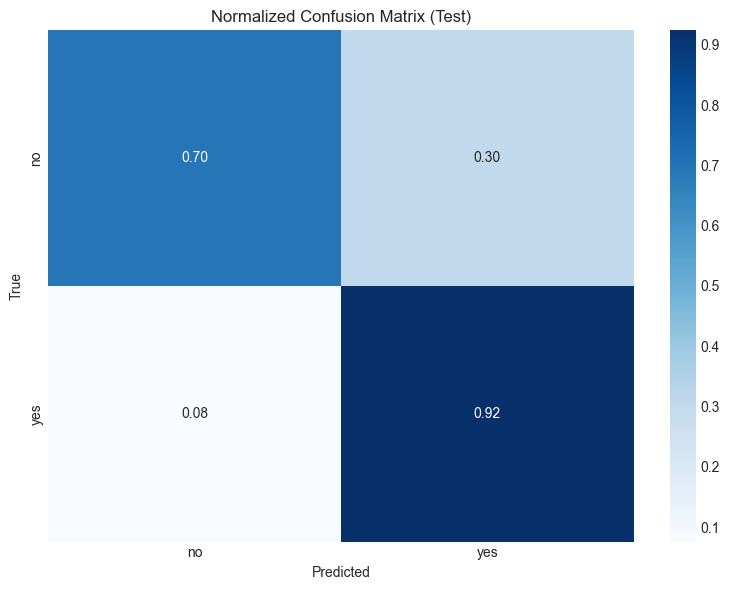

In [78]:
from sklearn.metrics import classification_report, confusion_matrix

y_test_pred = best_model.predict(X_test)

print("Test classification report:\n",
      classification_report(y_test, y_test_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

In [79]:
# Print which features are the most influencial for the best model if possible
if hasattr(best_model.named_steps['clf'], 'feature_importances_'):
    importances = best_model.named_steps['clf'].feature_importances_
    feature_importance_pairs = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

    print("\nTop 50 Feature Importances:")
    for fname, importance in feature_importance_pairs[:50]:
        print(f"{fname}: {importance:.4f}")


Top 50 Feature Importances:
any_touch: 0.0496
finger_1_pressures_velocity_mean: 0.0367
finger_2_pressures_velocity_mean: 0.0305
finger_1_pressures_velocity_max: 0.0284
motor_angle_range: 0.0279
finger_3_pressures_velocity_max: 0.0275
touch_spread: 0.0260
motor_velocity_std: 0.0223
active_moving_fingers: 0.0219
motor_angle_std: 0.0190
finger_1_touch_reactivations: 0.0189
max_simultaneous_touches: 0.0172
avg_active_touches: 0.0161
finger_3_pressures_velocity_std: 0.0152
finger_3_pressures_velocity_mean: 0.0148
total_active_touch_samples: 0.0143
finger_2_touch_reactivations: 0.0125
finger_3_touch_reactivations: 0.0121
finger_3_min_touch_duration: 0.0120
finger_1_min_touch_duration: 0.0120
finger_2_min_touch_duration: 0.0118
finger_1_pressures_velocity_std: 0.0117
finger_2_pressures_velocity_max: 0.0111
finger_4_pressures_velocity_std: 0.0100
motor_velocity_mean: 0.0091
finger_3_mean_touch_duration: 0.0087
finger_4_pressures_velocity_max: 0.0086
touch_spread_log: 0.0081
finger_4_touch_rea

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       118,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,554 (623.26 KB)

 Trainable params: 159,554 (623.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
380/380 - 1s - 3ms/step - accuracy: 0.7792 - loss: 0.4466 - val_accuracy: 0.7942 - val_loss: 0.4747
Epoch 2/100
380/380 - 1s - 2ms/step - accuracy: 0.8387 - loss: 0.3455 - val_accuracy: 0.8056 - val_loss: 0.5406
Epoch 3/100
380/380 - 1s - 1ms/step - accuracy: 0.8554 - loss: 0.3151 - val_accuracy: 0.8466 - val_loss: 0.5156
Epoch 4/100
380/380 - 1s - 1ms/step - accuracy: 0.8691 - loss: 0.2868 - val_accuracy: 0.8132 - val_loss: 0.5900
Epoch 5/100
380/380 - 1s - 1ms/step - accuracy: 0.8773 - loss: 0.2685 - val_accuracy: 0.8330 - val_loss: 0.5447
Epoch 6/100
380/380 - 1s - 1ms/step - accuracy: 0.8892 - loss: 0.2527 - val_accuracy: 0.8337 - val_loss: 0.5108
Epoch 7/100
380/380 - 1s - 1ms/step - accuracy: 0.8932 - loss: 0.2407 - val_accuracy: 0.8360 - val_loss: 0.5206
Epoch 8/100
380/380 - 1s - 1ms/step - accuracy: 0.9040 - loss: 0.2243 - val_accuracy: 0.8459 - val_loss: 0.5233
Epoch 9/100
380/380 - 1s - 1ms/step - accuracy: 0.9038 - loss: 0.2209 - val_accuracy: 0.8527 - val_loss:

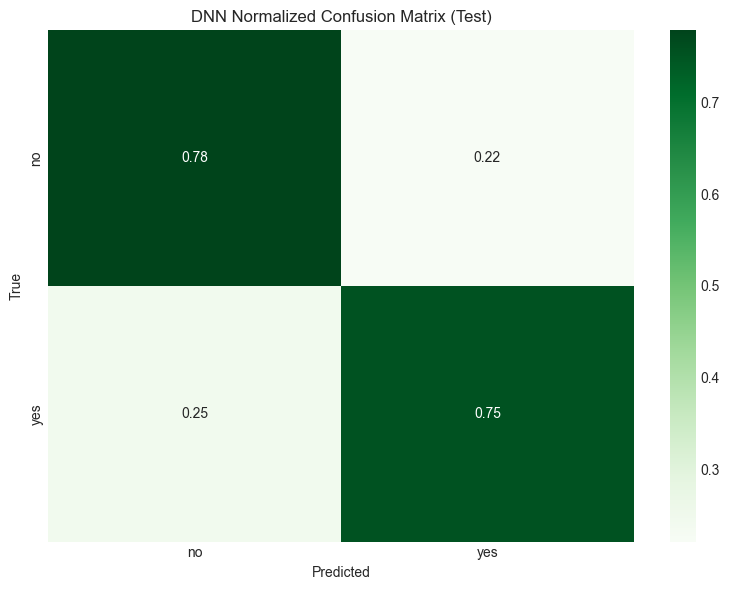

In [80]:
# Drain a DNN on the same data for comparison
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_dnn_model(input_shape, num_classes):
    model = keras.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

dnn_model = create_dnn_model(input_shape=(X_train.shape[1],), num_classes=len(le.classes_))
dnn_model.summary()
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
history = dnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=2
)
# Evaluate on test set
test_loss, test_accuracy = dnn_model.evaluate(X_test, y_test, verbose=0)
print(f"DNN Test Accuracy: {test_accuracy:.4f}")

y_test_dnn_pred_probs = dnn_model.predict(X_test)
y_test_dnn_pred = np.argmax(y_test_dnn_pred_probs, axis=1)
print("DNN Test classification report:\n",
      classification_report(y_test, y_test_dnn_pred, target_names=le.classes_))

cm_dnn = confusion_matrix(y_test, y_test_dnn_pred)
cm_dnn_norm = cm_dnn.astype("float") / cm_dnn.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dnn_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DNN Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()
        

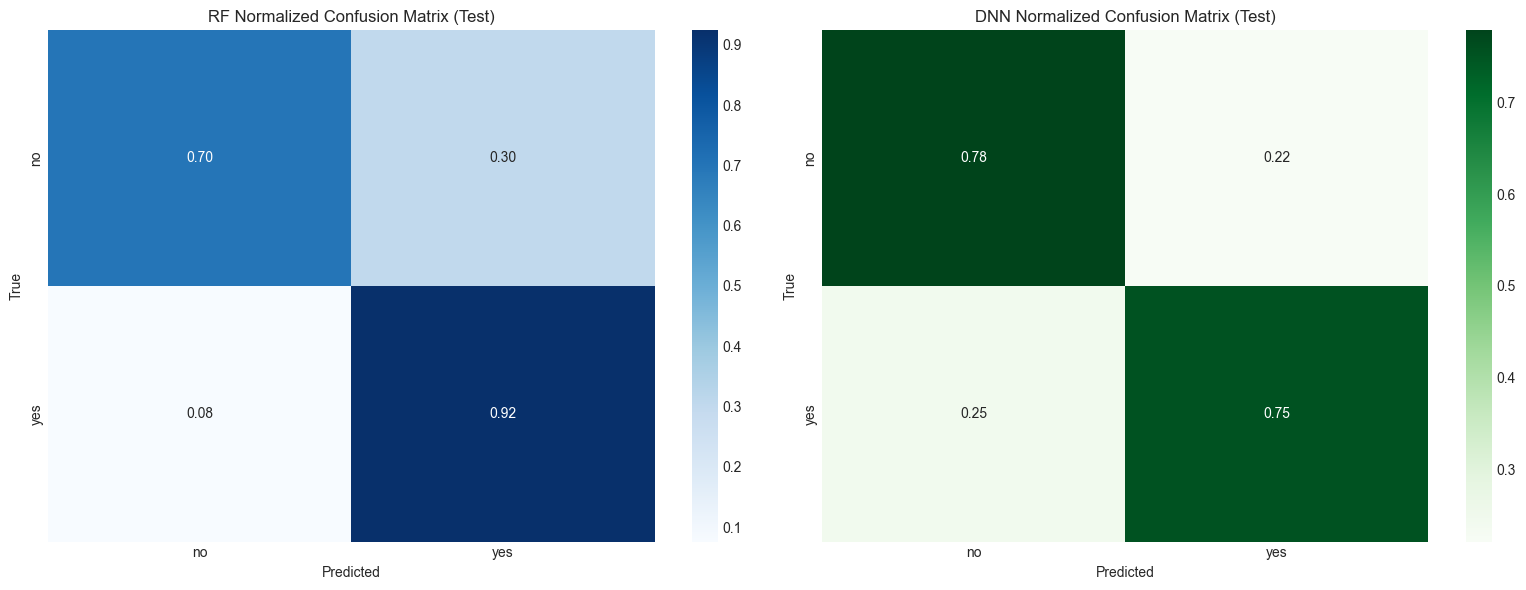

In [81]:
# compare the confusion matrixes and show a plot comparing both models
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RF Normalized Confusion Matrix (Test)")
plt.subplot(1, 2, 2)
sns.heatmap(cm_dnn_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DNN Normalized Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

Szenarien classification report:
               precision    recall  f1-score   support

          no       0.92      1.00      0.96      3844
         yes       0.00      0.00      0.00       319

    accuracy                           0.92      4163
   macro avg       0.46      0.50      0.48      4163
weighted avg       0.85      0.92      0.89      4163



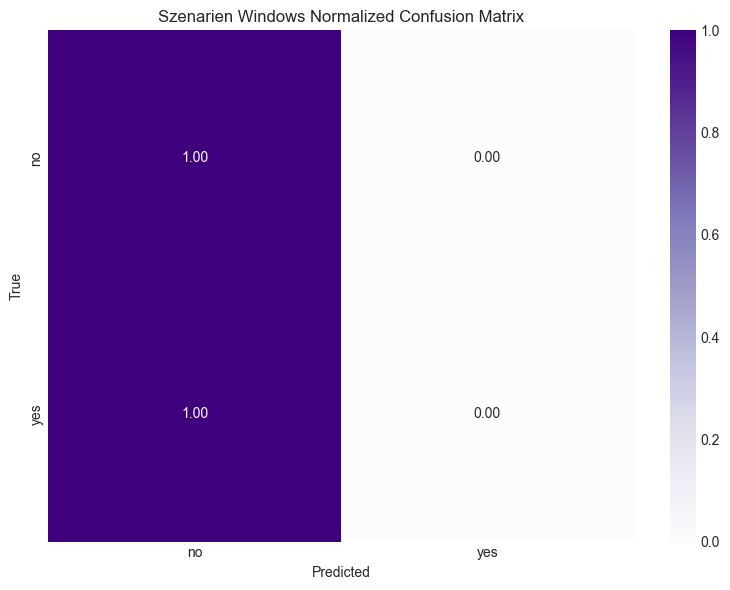

In [82]:
# Run the best model with the szenarien windows and print classification report
y_szenarien_pred = best_model.predict(X_szenarien_win)
print("Szenarien classification report:\n",
      classification_report(y_szenarien_win_int, y_szenarien_pred, target_names=le.classes_))

cm_szenarien = confusion_matrix(y_szenarien_win_int, y_szenarien_pred)
cm_szenarien_norm = cm_szenarien.astype("float") / cm_szenarien.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_szenarien_norm, annot=True, fmt=".2f",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Szenarien Windows Normalized Confusion Matrix")
plt.tight_layout()
plt.show()